<a href="https://colab.research.google.com/github/voronv27/Lab2/blob/main/03_rnn_and_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# set random seed
import os, random
import numpy as np
import torch
def seed_everything(seed: int = 42):
 random.seed(seed)
 np.random.seed(seed)
 os.environ["PYTHONHASHSEED"] = str(seed)
 torch.manual_seed(seed)
 torch.cuda.manual_seed_all(seed)
 torch.backends.cudnn.benchmark = False
 torch.backends.cudnn.deterministic = True

seed_everything(42)
rng = np.random.default_rng(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load data as torch tensor
files = ['body_acc_x_train.txt',
         'body_acc_y_train.txt',
         'body_acc_z_train.txt',
         'body_gyro_x_train.txt',
         'body_gyro_y_train.txt',
         'body_gyro_z_train.txt',
         'total_acc_x_train.txt',
         'total_acc_y_train.txt',
         'total_acc_z_train.txt' ]

# data will be in shape (C, N, T)
x = []
for file in files:
    x.append(torch.from_numpy(np.loadtxt('drive/MyDrive/ColabData/lab2/Inertial_Signals/' + file)))

# convert to (N, C, T)
x = torch.stack(x).permute(1, 0, 2) #rearranged so datapoints are 128 time steps with 9 features

y = torch.from_numpy(np.loadtxt('drive/MyDrive/ColabData/lab2/y_train.txt'))

print(x.shape)
print(y.shape)

torch.Size([7352, 9, 128])
torch.Size([7352])


In [ ]:
from sklearn.model_selection import train_test_split
import torch.nn.functional as F


X_train, X_val, Y_train, Y_val = train_test_split(x, y, random_state = 67, test_size=0.3)

X_test, X_dev, Y_test, Y_dev = train_test_split(X_val, Y_val,
                                                random_state = 67,
                                                test_size=0.5)

Y_train = F.one_hot(Y_train.long()- 1, num_classes=6).float()
Y_test = F.one_hot(Y_test.long()- 1, num_classes=6).float()
Y_dev = F.one_hot(Y_dev.long()- 1, num_classes=6).float()


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test = torch.tensor(Y_test, dtype=torch.float32).to(device)
X_dev = torch.tensor(X_dev, dtype=torch.float32).to(device)
Y_dev = torch.tensor(Y_dev, dtype=torch.float32).to(device)


print(X_train.shape)

torch.Size([5146, 9, 128])


/tmp/ipykernel_666/924158746.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
/tmp/ipykernel_666/924158746.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)
/tmp/ipykernel_666/924158746.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
/tmp/ipykernel_666/924158746.py:21: UserWarning: To copy construct from a tensor, it is recommended to use s

In [ ]:
import matplotlib.pyplot as plt

def plot_dev_train_loss(dev_loss, train_loss, title = ""):
  plt.plot(train_loss, label='train')
  plt.plot(dev_loss, label='dev')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title(title)
  plt.legend()
  plt.show()

#Core Sequence Model (LSTM)

We chose to use an LSTM for our core sequence model. LSTM models have better long-term memory than GRU models since they have a separate cell state. Being able to remember previous motion/movements better can help classify the current movement better (different people will walk/sit/etc differently, so the model having good long-term memory of that person's movement patterns will help classify future movements better).

In [ ]:
from torch import nn
import torch

class LSTMNetwork(nn.Module):
  def __init__(self, n_features, n_hidden, n_output, loss_function = nn.CrossEntropyLoss):
    super().__init__()
    self.hidden_size = n_hidden

    self.rnn = nn.LSTM(input_size=n_features,
                      hidden_size=n_hidden,
                      num_layers=1,
                      batch_first=True)

    self.fc = nn.Linear(n_hidden, n_output)
    self.loss_function = loss_function()
    self.output_activation = nn.Softmax(dim=1)

    self.optimizer = torch.optim.AdamW(self.parameters(), lr=0.01, weight_decay=0.001)


  def forward(self, x):
    rnn_out, h_n = self.rnn(x)

    last_output = rnn_out[:, -1, :]
    output = self.fc(last_output)

    return output

  def train_step(self, X, y):
    self.train()

    #forward propagation
    pred = self(X)
    loss = self.loss_function(pred, y)

    #back propagation
    loss.backward()
    self.optimizer.step()
    self.optimizer.zero_grad()

    return loss

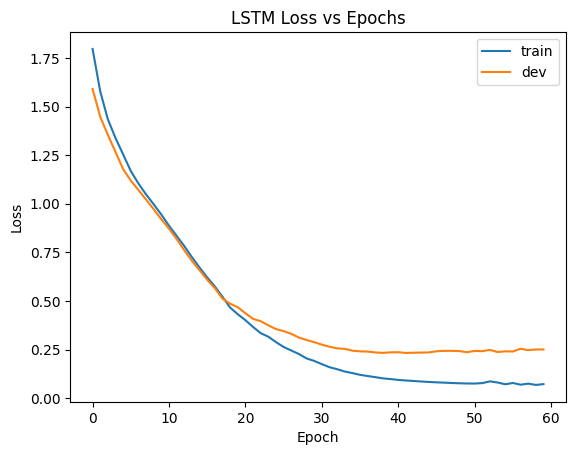



Test loss: 0.18952958285808563


Test accuracy: 0.9238440616500453


In [ ]:
from sklearn.metrics import accuracy_score

n_hidden = 128
n_features = X_train.shape[2]
n_output = 6
epochs = 60

LSTM_model = LSTMNetwork(n_features, n_hidden, n_output)
LSTM_model.to(device)

train_losses = list()
dev_losses = list()

for t in range(epochs):
  loss = LSTM_model.train_step(X_train, Y_train)
  train_losses.append(loss.item())

  LSTM_model.eval()
  with torch.no_grad():
    pred = LSTM_model(X_dev)
    dev_loss = LSTM_model.loss_function(pred, Y_dev)
    dev_losses.append(dev_loss.item())

plot_dev_train_loss(dev_losses, train_losses, "LSTM Loss vs Epochs")

Y_pred = LSTM_model(X_test)
test_loss = LSTM_model.loss_function(Y_pred, Y_test)
print("\n\nTest loss:", test_loss.item())
accuracy = accuracy_score(Y_test.argmax(dim=-1), Y_pred.argmax(dim=-1))
print("\n\nTest accuracy:", accuracy)

#Training Robustness

In [ ]:
from torch.optim import lr_scheduler

class RobustLSTM(LSTMNetwork):
  def __init__(self, n_features, n_hidden, n_output, loss_function = nn.CrossEntropyLoss):
    super().__init__(n_features, n_hidden, n_output, loss_function)
    self.scheduler = lr_scheduler.StepLR(self.optimizer, step_size=30, gamma=0.1)

  def train_step(self, X, y):
    self.train()

    # forward propagation
    pred = self(X)
    loss = self.loss_function(pred, y)

    # back propagation
    loss.backward()

    torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
    # adding gradient clipping

    self.optimizer.step()
    self.optimizer.zero_grad()

    self.scheduler.step()

    return loss


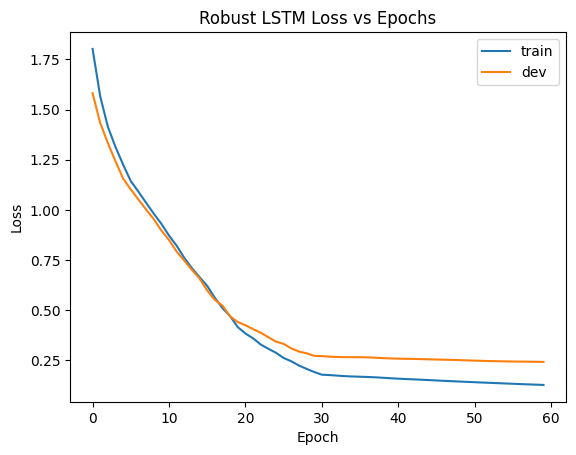



Test loss: 0.2277115434408188


Test accuracy: 0.9129646418857661


In [ ]:
robust_model = RobustLSTM(n_features, n_hidden, n_output)
robust_model.to(device)

train_losses = list()
dev_losses = list()

for t in range(epochs):
  loss = robust_model.train_step(X_train, Y_train)
  train_losses.append(loss.item())

  robust_model.eval()
  with torch.no_grad():
    pred = robust_model(X_dev)
    dev_loss = robust_model.loss_function(pred, Y_dev)
    dev_losses.append(dev_loss.item())

plot_dev_train_loss(dev_losses, train_losses, "Robust LSTM Loss vs Epochs")

Y_pred = robust_model(X_test)
test_loss = robust_model.loss_function(Y_pred, Y_test)
print("\n\nTest loss:", test_loss.item())
accuracy = accuracy_score(Y_test.argmax(dim=-1), Y_pred.argmax(dim=-1))
print("\n\nTest accuracy:", accuracy)

1 WALKING

2 WALKING_UPSTAIRS

3 WALKING_DOWNSTAIRS

4 SITTING

5 STANDING

6 LAYING

#Final Evaluation

Get the actual test data (not our train test data):

In [ ]:
# load data as torch tensor
files = ['body_acc_x_test.txt',
         'body_acc_y_test.txt',
         'body_acc_z_test.txt',
         'body_gyro_x_test.txt',
         'body_gyro_y_test.txt',
         'body_gyro_z_test.txt',
         'total_acc_x_test.txt',
         'total_acc_y_test.txt',
         'total_acc_z_test.txt' ]

# data will be in shape (C, N, T)
x_test = []
for file in files:
    x_test.append(torch.from_numpy(np.loadtxt('drive/MyDrive/ColabData/lab2/Test/Inertial_Signals/' + file)))

# convert to (N, C, T)
x_test = torch.stack(x_test).permute(1, 0, 2) #rearranged so datapoints are 128 time steps with 9 features

y_test = torch.from_numpy(np.loadtxt('drive/MyDrive/ColabData/lab2/Test/y_test.txt'))
y_test = F.one_hot(y_test.long()- 1, num_classes=6).float()

# convert to tensors
x_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(Y_test, dtype=torch.float32).to(device)



/tmp/ipykernel_666/2013123661.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test = torch.tensor(X_test, dtype=torch.float32).to(device)
/tmp/ipykernel_666/2013123661.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(Y_test, dtype=torch.float32).to(device)


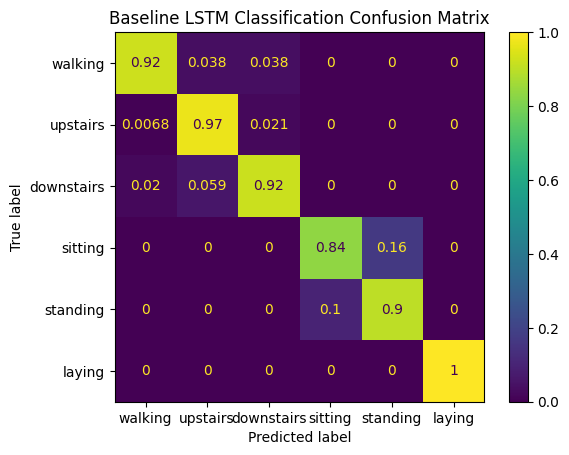

<Figure size 640x480 with 0 Axes>

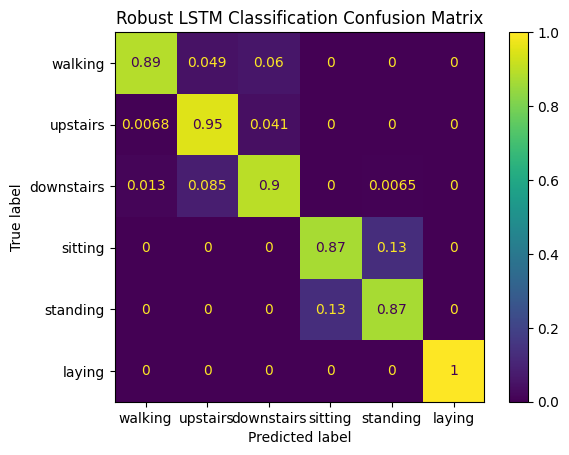

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, title):
  y_true_categorical = np.argmax(y_true, axis=1)
  y_pred_categorical = np.argmax(y_pred, axis=1)

  display_labels = ["walking", "upstairs", "downstairs",\
                    "sitting", "standing", "laying"]
  cm = confusion_matrix(y_true_categorical, y_pred_categorical)

  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

  cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                                      display_labels=display_labels)
  cm_display.plot()
  plt.title(title)
  plt.show()
  plt.clf()


LSTM_y_pred = LSTM_model(x_test)
plot_confusion_matrix(y_test.cpu().detach().numpy(),
                      LSTM_y_pred.cpu().detach().numpy(),
                      "Baseline LSTM Classification Confusion Matrix")

Robust_y_pred = robust_model(x_test)
plot_confusion_matrix(y_test.cpu().detach().numpy(),
                      Robust_y_pred.cpu().detach().numpy(),
                      "Robust LSTM Classification Confusion Matrix")

Between the two models, standing and sitting were most commonly confused for one another. This makes sense, as the gyroscopic profile of sitting and standing are the two most similar, both being stationary activities where the instrument is in a similar position. For similar reasons, the moving classes were all occasionally confused with one another. However, the overall performance of both models was strong, though the baseline outperformed the modified LSTM in every class except for sitting prediction. This may be a product of overpenalizing regularization. It may be worth it in the future to allow tweaks to weight decay for the "robust" model class.

#Inference Function + Latency

###Inference Function

We will save our `LSTM_model` as our model checkpoint, produced by the core sequence model run above ("baseline_LSTM" in our experiment log).

In [ ]:
# save model checkpoint
state_dict = LSTM_model.state_dict()
torch.save(state_dict, 'baseline_LSTM.pth')

In [ ]:
# load model from checkpoint to use in predict_activity
# (ensure device is cpu for latency tests)
model = LSTMNetwork(n_features, n_hidden, n_output)
model.load_state_dict(torch.load('baseline_LSTM.pth'))
device = 'cpu'
model.to(device)
model.eval()

LSTMNetwork(
  (rnn): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=6, bias=True)
  (loss_function): CrossEntropyLoss()
  (output_activation): Softmax(dim=1)
)

In [ ]:
def predict_activity(window):
  model.eval()

  # make prediction, return (label, probs)
  with torch.no_grad():
    pred = model(window)
    pred = pred.cpu().detach().numpy()
  return np.argmax(pred), pred


### Measure Latency

In [ ]:
import time

# will measure latency over 300 samples
windows = X_test[:300]
LSTM_times = []

for window in windows:
  window = window.unsqueeze(0)
  start = time.time()
  predict_activity(window)
  end = time.time()
  LSTM_times.append(end - start)

print(f"Average latency: {np.mean(LSTM_times):.4f} seconds")

Average latency: 0.0005 seconds


Our average inference time per window (over 300 windows) is 0.0005 seconds, which is pretty quick. This is feasible for near-real-time use, as it is fast enough that it will appear like "real-time" to a user. In the first place, each window duration is 2.56 seconds (measured every 1.28 seconds), meaning our model predicts much faster than the rate at which each window is measured.

#Graduate Task

I chose to get bootstrap confidence intervals for macro-F1.

In [ ]:
from sklearn.metrics import f1_score

bootstrap_samples = 500
seed_everything(42)
rng = np.random.default_rng(42)

y_true = y_test.cpu().detach().numpy()
y_pred = LSTM_y_pred.cpu().detach().numpy()

# get labels, not probabilities
y_true = np.argmax(y_true, axis=1)
y_pred = np.argmax(y_pred, axis=1)

f1_scores = []
for i in range(bootstrap_samples):
  # get indices with replacement
  indices = rng.integers(0, len(y_true), len(y_true))

  f1 = f1_score(
      y_true[indices],
      y_pred[indices],
      average='macro'
  )
  f1_scores.append(f1)

macro_f1 = np.mean(f1_scores)
print(f"Average macro-F1: {macro_f1:.4f}")

f1_scores = np.array(f1_scores)
lower = np.percentile(f1_scores, 2.5)
upper = np.percentile(f1_scores, 97.5)
print(f"95% confidence interval: [{lower:.4f}, {upper:.4f}]")

Average macro-F1: 0.9240
95% confidence interval: [0.9078, 0.9391]


For the 95% confidence interval I chose, we assume that 95% of the time, the macro-F1 score for a sampling of the test data will be within the 2.5 to 97.5 percentiles of all our macro-F1 scores. So, 95% of the macro-F1 scores across 500 resamples were between 0.9078 and 0.9391. That means that the macro-F1 score fluctuates an average of 4% depending on the sampling, showing that there is little uncertainty and the effects of chance error in the sample shouldn't affect the macro-F1 metric too much.

# Model Card


###Model name + version:  
Our model is named `baseline_LSTM` in our experiment log and has the class name `LSTMNetwork`. This is the first version of the model, which had better performance than the RobustLSTM model.

###Intended use:  
Model is a classification Long-Short-Term Memory recurrent neural network designed for windowed time-series data. The intended use is to classify a person's movement. Model input is 9 dimensional (X,Y,Z direction for each: body acceleration, gyroscop, total acceleration) motion sensor data over a 128 time-step window. Target classification a label from 1 of 6 (walking forward, walking upstairs, walking downstairs, standing, sitting, or laying down).

###Not intended use:  

Model is not designed for input windows that do not adhere to the discussed setup. Attepting inference on a window of non-time-series and non-motion-sensor-data --even if in the correct shape-- will yield nonsense classification.

###Training data:  

Model was trained on 7,352 input windowed time-series windows along 9 dimensions of sensor signals. The sensor signals (accelerometer and gyroscope) were sampled in fixed-width sliding windows of 2.56 sec and 50% overlap (128 readings/window). This means each new window starts its reading after the previous window is halfway through its duration (2.56/2 = every 1.28 seconds).


###Evaluation protocol (including subject-disjoint split):

Training data was split into a train-test-dev split (0.7-0.15-0.15). For development we effectively had 2 validation sets (each 1103). For the inference task, we use a set of 300 windows reserved by the dataset authors.


###Primary metrics + results:  
Our primary metric was accuracy. For our chosen baseline_LSTM model, the end accuracy was 92.38%. To see the accuracy scores of all other models, you can refer to our [experiment log](https://docs.google.com/spreadsheets/d/1ED-iCLEK9OIuyoAVxr-Ng2QhX_DmYLD0qTX3sJ_tuY8/edit?usp=sharing).

###Key failure modes (what it gets wrong, when):  
Our model was fairly accurate (around 92% accurate), but the main point of failure was classifying between standing and sitting. Since these motions are similar in position and are stationary in motion, it is harder for the model to tell them apart. The model also confused walking up/down for some cases (though this was less of a failure point).

###Limitations (data coverage, sensor placement, domain shift):  

In our dataset, only a very small set of movements were recorded (walking, walking up/down stairs, standing, sitting, and laying), meaning the model will only be trained to characterize movements into one of those categories (as opposed to more complex movements such as running, dancing, falling, etc).

In addition, only 30 subjects were sampled. This is a small amount of people so the data may not reflect the general public's movement patterns as well. As an example, the age range of the participants was from 19-48, meaning that the movement of children and the elderly wasn't taken into account and the model most likely wouldn't be able to predict their actions as accurately (ex: walking with a cane or more slowly due to age would also affect sensor data).

The sensor placement of the smartphones used to track movement was on the waist, so the model would likely be worse at predicting movements if the smartphone was elsewhere (pocket, hand, etc).

###Ethics & privacy notes:  
The datasest we used to train this model was downloaded from https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

and is licensed under a [Creative Commons Attribution 4.0 International](https://creativecommons.org/licenses/by/4.0/legalcode) (CC BY 4.0) license.

Use of this dataset in publications must be acknowledged by referencing the following publication [1]

[1] Davide Anguita, Alessandro Ghio, Luca Oneto, Xavier Parra and Jorge L. Reyes-Ortiz. A Public Domain Dataset for Human Activity Recognition Using Smartphones. 21th European Symposium on Artificial Neural Networks, Computational Intelligence and Machine Learning, ESANN 2013. Bruges, Belgium 24-26 April 2013.

This dataset is distributed AS-IS and no responsibility implied or explicit can be addressed to the authors or their institutions for its use or misuse. Any commercial use is prohibited.

As such, commercial use for our model is prohibited.

The data was acquired from a group of 30 volunteers and is ethically sourced.

###How to reproduce (seed, environment, checkpoint path):  
To reproduce our results, set the seed via the `seed_everything` function to 42, as well as calling `rng = np.random.default_rng(42)`. The environment we ran this experiment in is using the CPU device in Colab. Our checkpoint path, created by running the above code, is "baseline_LSTM.pth" (in the local directory).